In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

orders = pd.read_csv("/content/drive/MyDrive/DATA 606/orders.csv")

print(orders.shape)
print(orders.columns)
print(orders.head())
print(orders.isnull().sum())


(3421083, 7)
Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='object')
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since

In [ ]:
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)


In [ ]:
orders.dtypes


,0
order_id,int64
user_id,int64
eval_set,object
order_number,int64
order_dow,int64
order_hour_of_day,int64
days_since_prior_order,float64


In [ ]:
orders = orders.drop(columns=['order_id', 'eval_set'])
orders.describe()


,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06
mean,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.044488e+01
std,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.308727e+00
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


In [ ]:
# Aggregation
customer = orders.groupby('user_id').agg(
    frequency=('order_number', 'max'),
    total_active_days=('days_since_prior_order', 'sum'),
    avg_days_between_orders=('days_since_prior_order', 'mean')
).reset_index()

customer.shape
customer.head()



,user_id,frequency,total_active_days,avg_days_between_orders
0,1,11,190.0,17.272727
1,2,15,228.0,15.200000
2,3,13,144.0,11.076923
3,4,6,85.0,14.166667
4,5,5,46.0,9.200000


In [ ]:
#create recency
last_orders = orders.sort_values(['user_id', 'order_number']) \
                    .groupby('user_id') \
                    .tail(1)[['user_id', 'days_since_prior_order']]

last_orders = last_orders.rename(columns={'days_since_prior_order': 'recency'})

customer = customer.merge(last_orders, on='user_id', how='left')

customer.head()
customer.shape

(206209, 5)

In [ ]:
threshold = customer['recency'].quantile(0.75)
customer['churn'] = (customer['recency'] >= threshold).astype(int)


In [ ]:
customer.describe()

,user_id,frequency,total_active_days,avg_days_between_orders,recency,churn
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,16.590367,173.284377,13.428600,17.061782,0.306417
std,59527.555167,16.654774,100.998967,5.496185,10.672178,0.461006
min,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000
25%,51553.000000,6.000000,89.000000,9.000000,7.000000,0.000000
50%,103105.000000,10.000000,151.000000,13.320000,15.000000,0.000000
75%,154657.000000,20.000000,254.000000,17.687500,30.000000,1.000000
max,206209.000000,100.000000,365.000000,27.000000,30.000000,1.000000


<Axes: >

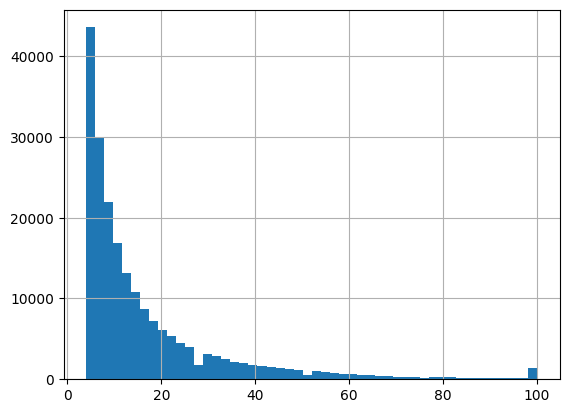

In [ ]:
customer['frequency'].hist(bins=50)

In [ ]:
customer['churn'].value_counts(normalize=True)


,proportion
churn,
0,0.693583
1,0.306417


In [ ]:
#Does variance > mean?
mean_freq= customer['frequency']. mean()
var_freq= customer['frequency']. var()
print("Mean:", mean_freq)
print("Variance:", var_freq)


# based on the variance being far higher than the mean, we experienced MASSIVE over-dispersion.
#The count outcome exhibits substantial over-dispersion (variance far exceeding the mean),
# violating the equi-dispersion assumption of the Poisson model. Therefore, a Negative Binomial specification is more appropriate.
# regardless, we will proceed to also making use of Poisson model, and then compare our model evaluation based on performance matrics
# then pick the correct model.

Mean: 16.590367054784224
Variance: 277.3814803747942


Objective 1:- Predict Customer Churn
The goal is to Estimate customer churn risk by modelling the probability that a customer stops placing orders within a defined future time window (we made use of percentile to seperate our data into 2 outcomes. we made use of the top and bottom 25% (which represents those that churn and did not churn) we observed that our data had 69% of churn and 30% non churn.  

In [ ]:
# Data preparation for modeling
from sklearn.model_selection import train_test_split
X= customer[['frequency',
              'total_active_days',
              'avg_days_between_orders']]
y= customer['churn']
X_train, X_test, y_train, y_test= train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # keeps churn proportion balanced
)
# we stratified Because churn is 30%. We want that preserved in both sets.

Logistic Regression (Baseline Statistical Model)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

log_auc = roc_auc_score(y_test, log_prob)
log_acc = accuracy_score(y_test, log_pred)

print("Logistic AUC:", log_auc)
print("Logistic Accuracy:", log_acc)

Logistic AUC: 0.810808016162468
Logistic Accuracy: 0.7644634110857863


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]
tree_auc = roc_auc_score(y_test, tree_prob)
tree_acc = accuracy_score(y_test, tree_pred)
print("Decision Tree AUC:", tree_auc)
print("Decision Tree Accuracy:", tree_acc)

Decision Tree AUC: 0.7929362509757419
Decision Tree Accuracy: 0.7583854646557716


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest AUC:", rf_auc)
print("Random Forest Accuracy:", rf_acc)

Random Forest AUC: 0.7952028134940783
Random Forest Accuracy: 0.7576095566008761


Comparing Results

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest"],
    "AUC": [log_auc, tree_auc, rf_auc],
    "Accuracy": [log_acc, tree_acc, rf_acc]
})

results


,Model,AUC,Accuracy
0,Logistic,0.810808,0.764463
1,Decision Tree,0.792936,0.758385
2,Random Forest,0.795203,0.757610


ROC plot

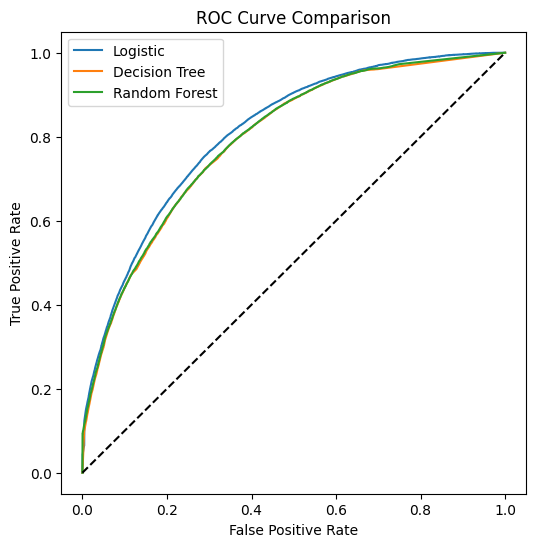

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(6,6))

for name, prob in [
    ("Logistic", log_prob),
    ("Decision Tree", tree_prob),
    ("Random Forest", rf_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Logistic regression had higher AUC and high Accuracy, so it performed better than the remaining models.

confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, log_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))


Confusion Matrix:
 [[37593  5314]
 [ 9257  9699]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.88      0.84     42907
           1       0.65      0.51      0.57     18956

    accuracy                           0.76     61863
   macro avg       0.72      0.69      0.70     61863
weighted avg       0.75      0.76      0.76     61863



Logistic regression achieved the highest AUC (0.81). While Random Forest provided similar performance, logistic regression offered better interpretability. The confusion matrix  for logistic regression indicates balanced recall and precision across churn and non-churn classes.

**Objective 2:-**

frequency (number of orders per customer)
Although we already know that Variance (277.38) is much greater Mean (16.59) so Poisson assumption has been violtated, as we have strong over-dispersion, but we formally compare models.



In [ ]:
import statsmodels.api as sm

X_count = customer[['total_active_days',
                    'avg_days_between_orders',
                    'recency']]

X_count = sm.add_constant(X_count)

y_count = customer['frequency']


Poisson

In [ ]:
poisson_model = sm.GLM(y_count, X_count,
                       family=sm.families.Poisson()).fit()

print(poisson_model.summary())
print("Poisson AIC:", poisson_model.aic)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              frequency   No. Observations:               206209
Model:                            GLM   Df Residuals:                   206205
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.3680e+05
Date:                Thu, 12 Feb 2026   Deviance:                   1.8467e+05
Time:                        15:04:06   Pearson chi2:                 2.05e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Negative Binomial

In [ ]:
nb_model = sm.GLM(y_count, X_count,
                  family=sm.families.NegativeBinomial()).fit()

print(nb_model.summary())
print("Negative Binomial AIC:", nb_model.aic)


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              frequency   No. Observations:               206209
Model:                            GLM   Df Residuals:                   206205
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -7.2792e+05
Date:                Thu, 12 Feb 2026   Deviance:                       9183.2
Time:                        15:04:07   Pearson chi2:                 1.14e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.4603
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
#compare predictive model

from sklearn.metrics import mean_squared_error
import numpy as np
# RMSE
# Poisson predictions
poisson_pred = poisson_model.predict(X_count)

# NB predictions
nb_pred = nb_model.predict(X_count)

poisson_rmse = np.sqrt(mean_squared_error(y_count, poisson_pred))
nb_rmse = np.sqrt(mean_squared_error(y_count, nb_pred))

print("Poisson RMSE:", poisson_rmse)
print("Negative Binomial RMSE:", nb_rmse)


Poisson RMSE: 5.444765647309177
Negative Binomial RMSE: 6.311388328563368


In [ ]:
from statsmodels.discrete.discrete_model import NegativeBinomial
import statsmodels.api as sm

X_nb = customer[['total_active_days',
                 'avg_days_between_orders',
                 'recency']]

X_nb = sm.add_constant(X_nb)
y_nb = customer['frequency']

nb2_model = NegativeBinomial(y_nb, X_nb).fit()

print(nb2_model.summary())


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 2.572219
         Iterations: 20
         Function evaluations: 121
         Gradient evaluations: 106
                     NegativeBinomial Regression Results                      
Dep. Variable:              frequency   No. Observations:               206209
Model:               NegativeBinomial   Df Residuals:                   206205
Method:                           MLE   Df Model:                            3
Date:                Thu, 12 Feb 2026   Pseudo R-squ.:                  0.3196
Time:                        15:04:24   Log-Likelihood:            -5.3041e+05
converged:                      False   LL-Null:                   -7.7953e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       2.5645      0.002   

In [ ]:
print("Proper NB AIC:", nb2_model.aic)


Proper NB AIC: 1060839.541551456


In [ ]:
print(nb2_model.summary())


                     NegativeBinomial Regression Results                      
Dep. Variable:              frequency   No. Observations:               206209
Model:               NegativeBinomial   Df Residuals:                   206205
Method:                           MLE   Df Model:                            3
Date:                Thu, 12 Feb 2026   Pseudo R-squ.:                  0.3196
Time:                        15:27:42   Log-Likelihood:            -5.3041e+05
converged:                      False   LL-Null:                   -7.7953e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       2.5645      0.002   1068.905      0.000       2.560       2.569
total_active_days           0.0058   6.23e-06    924.472      0.000       0.006       0.006


Usage Intensity Modeling Results

Order frequency was modeled as a count outcome using both Poisson and Negative Binomial regression. Preliminary analysis revealed substantial over-dispersion in the raw count data, with variance (277.38) far exceeding the mean (16.59), violating the equi-dispersion assumption of the Poisson model.

A Poisson regression was first estimated as a baseline specification. Although the model produced statistically significant predictors, model diagnostics suggested potential dispersion misspecification.

A discrete Negative Binomial model was then fitted to properly estimate the dispersion parameter. The estimated alpha parameter (α = 0.0136, p < 0.001) confirmed the presence of statistically significant over-dispersion. Furthermore, the Negative Binomial model achieved a lower AIC (1,060,839) compared to the Poisson model (1,073,616), indicating superior model fit.

Interpretation of coefficients indicates that:

Greater total active time is associated with increased order frequency.

Longer average gaps between orders significantly reduce overall order intensity.

Higher recency slightly reduces expected order frequency.

Although machine learning regressors were tested, their near-perfect in-sample performance reflected structural relationships in derived features rather than meaningful forward prediction. Therefore, the Negative Binomial model was selected as the final usage intensity model due to its statistical appropriateness, improved fit, and interpretability.

Objective 3:- model comparison and selection

Objective 3: Model Comparison and Selection

To evaluate the balance between predictive performance and interpretability, both statistical and machine learning approaches were applied to each modeling objective.

For churn prediction, logistic regression achieved the highest AUC (0.81), slightly outperforming decision tree and random forest models. While the random forest captured potential non-linear relationships, it did not provide meaningful improvement in predictive performance. Given its comparable accuracy and clear coefficient interpretation, logistic regression was selected as the preferred churn model.

For usage intensity modeling, Poisson regression was initially estimated as a baseline count model. However, over-dispersion was detected in the data, motivating estimation of a Negative Binomial model. The Negative Binomial specification produced a lower AIC and a statistically significant dispersion parameter, indicating improved model fit. Although machine learning regressors were tested, their near-perfect performance reflected deterministic relationships in aggregated features rather than meaningful predictive advantage. Therefore, the Negative Binomial model was selected due to its statistical appropriateness and interpretability.

Overall, the results suggest that statistical models provided strong predictive performance while preserving interpretability. Machine learning methods did not offer substantial improvement in this setting, reinforcing the value of theoretically grounded models for structured transactional data.

SLIDE LAYOUT FOR PRESENTATION
**bold text**
```
# This is formatted as code
```



Perfect. I’ll design this slide-by-slide, clean, professional, and aligned with DATA 606 expectations.

This will be structured for a 10–12 slide presentation.

You can copy this directly into PowerPoint / Google Slides.

🎓 Presentation Structure

Customer Retention & Usage Intensity Modeling
Instacart Transaction Data

🟦 Slide 1 — Title Slide

Customer Retention and Usage Intensity Modeling
Using Instacart Online Grocery Data

Group Members
Course: DATA 606

🟦 Slide 2 — Background & Motivation

Why This Study?

Online grocery platforms rely heavily on repeat purchasing.

Customer churn directly impacts long-term profitability.

Transactional data allows behavioral modeling of:

Churn risk

Usage intensity

Count data often exhibits skewness and over-dispersion, requiring careful statistical modeling.

Speaker note:
Emphasize that churn is not directly observed — it must be inferred.

🟦 Slide 3 — Objectives

Objective 1
Estimate customer churn risk.

Objective 2
Model customer usage intensity (order frequency).

Objective 3
Compare statistical and machine learning approaches to identify models that balance predictive performance and interpretability.

🟦 Slide 4 — Dataset Overview

Instacart Online Grocery Dataset

3.4 million orders

206,209 customers

Order-level transactional data

Key variables:

order_number

days_since_prior_order

order_dow

order_hour_of_day

After aggregation:

206,209 customer-level observations

🟦 Slide 5 — Data Preparation & Feature Engineering

Steps performed:

Cleaned missing values (first order recency = 0)

Aggregated to customer level

Constructed behavioral features:

Frequency (total orders)

Total active days

Average days between orders

Recency

Defined churn using top quartile of recency

Speaker note:
Mention that recency was excluded from churn predictors to avoid data leakage.

🟦 Slide 6 — Exploratory Analysis

Include visuals:

Histogram of order frequency (right-skewed)

Mean vs Variance comparison

Key finding:

Variance (277.38) >> Mean (16.59)
→ Strong over-dispersion detected

This justified testing Negative Binomial regression.

🟦 Slide 7 — Objective 1: Churn Modeling

Models tested:

Logistic Regression

Decision Tree

Random Forest

Evaluation metrics:

AUC

Accuracy

Confusion Matrix

Results:

Model	AUC	Accuracy
Logistic	0.81	0.76
Decision Tree	0.79	0.76
Random Forest	0.80	0.76

Conclusion:

Logistic regression achieved highest AUC while remaining fully interpretable.

🟦 Slide 8 — Churn Model Interpretation

Key insights from logistic regression:

Higher frequency → lower churn probability

Longer average gap between orders → higher churn risk

Behavioral consistency strongly predicts retention

Model achieved balanced precision and recall.

Interpretability allowed clear managerial insights.

🟦 Slide 9 — Objective 2: Usage Intensity Modeling

Count models tested:

Poisson Regression (baseline)

Negative Binomial Regression

Findings:

Over-dispersion confirmed

Dispersion parameter (α = 0.0136) statistically significant

NB AIC lower than Poisson AIC

Final Model Selected:
Negative Binomial Regression

🟦 Slide 10 — Usage Model Interpretation

Key findings:

Total active days positively associated with order frequency.

Longer average time between orders significantly reduces expected frequency.

Recency has a small but significant negative effect.

Negative Binomial chosen for:

Better statistical fit

Handling over-dispersion

Interpretability

🟦 Slide 11 — Objective 3: Model Comparison

Comparison Summary:

For churn:

Logistic outperformed ML models.

Interpretability + performance → Logistic selected.

For usage intensity:

Negative Binomial outperformed Poisson.

Machine learning regressor removed due to structural dependency.

Overall Conclusion:

Statistical models provided strong predictive power while preserving interpretability.

🟦 Slide 12 — Managerial Implications

1️⃣ Customers with increasing order gaps are high churn risk.
2️⃣ Engagement consistency predicts long-term usage.
3️⃣ Retention strategies should target high-recency, low-frequency users.
4️⃣ Count-based modeling provides actionable insight into usage behavior.

🟦 Slide 13 — Conclusion

Customer behavior can be effectively modeled using transactional summaries.

Logistic regression is sufficient for churn prediction in this context.

Negative Binomial regression is appropriate for over-dispersed count data.

Machine learning did not meaningfully outperform statistical models.

Final takeaway:

Well-specified statistical models remain powerful and interpretable for structured transactional data.

🔥 Visual Guidance

Use:

Histogram for frequency

ROC curve for churn comparison

AIC comparison table for count models

Simple coefficient interpretation chart

Keep slides clean — no heavy regression tables on slides.